# M5 Forecasting — Notebook 1: Exploratory Data Analysis

**Pipeline:** EDA → Feature Engineering → Forecasting → Optimization

- Sales distributions and sparsity (intermittency)
- Temporal patterns: trend, seasonality, weekly cycle
- Price dynamics and SNAP promotion effects
- Autocorrelation analysis to justify lag feature choices
- Store × category decomposition


In [ ]:
import sys, pathlib, os

os.environ["ENV"] = "kaggle" 

# ── Source files path ──────────────────────────────────────────────────────────
# Kaggle  : set to your dataset path
# Local   : set to the project root (folder containing src/)
# Override: export SRC_ROOT=/your/path before running
SRC_ROOT = os.environ.get(
    "SRC_ROOT",
    "/path/to/the/folder/containing/src/and/config.py"
)

if SRC_ROOT not in sys.path:
    sys.path.insert(0, SRC_ROOT)

# ── Load config (handles all other paths automatically) ────────────────────────
from config import print_config, DATA_DIR, CACHE_DIR, OUTPUT_DIR, MODEL_DIR, MLFLOW_URI
print_config()


Environment : kaggle
DATA_DIR    : /kaggle/input/competitions/m5-forecasting-accuracy/
CACHE_DIR   : /kaggle/working/store_cache
OUTPUT_DIR  : /kaggle/working/outputs
MODEL_DIR   : /kaggle/working/models
MLFLOW_URI  : /kaggle/working/mlruns
N_ITEMS     : ALL
N_CV_SPLITS : 3


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

COLORS = {
    'green':'#48bb78', 'blue':'#63b3ed', 'orange':'#f6ad55',
    'red':'#fc8181',   'gray':'#718096', 'purple':'#b794f4',
}
plt.rcParams.update({
    'figure.facecolor':'#0f1117', 'axes.facecolor':'#1a202c',
    'axes.edgecolor':'#2d3748',   'axes.labelcolor':'#e2e8f0',
    'xtick.color':'#a0aec0',      'ytick.color':'#a0aec0',
    'text.color':'#e2e8f0',       'grid.color':'#2d3748',
    'grid.linewidth':0.5,         'font.family':'monospace',
    'axes.titlesize':11,          'axes.titleweight':'bold',
})
print('Libraries loaded ✓')


Libraries loaded ✓


## 1. Load Data

In [4]:
sales    = pd.read_csv(f'{DATA_DIR}sales_train_validation.csv')
calendar = pd.read_csv(f'{DATA_DIR}calendar.csv')
prices   = pd.read_csv(f'{DATA_DIR}sell_prices.csv')

id_cols  = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
day_cols = [c for c in sales.columns if c.startswith('d_')]

print(f'Sales    : {sales.shape}')
print(f'Calendar : {calendar.shape}')
print(f'Prices   : {prices.shape}')
sales.head(3)


Sales    : (30490, 1919)
Calendar : (1969, 14)
Prices   : (6841121, 4)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1


## 2. Dataset Overview & Sparsity

In [5]:
sales_vals  = sales[day_cols].values
zero_rate   = (sales_vals == 0).mean()
series_mean = sales_vals.mean(axis=1)

print(f'Items (SKUs)       : {sales["item_id"].nunique():,}')
print(f'Stores             : {sales["store_id"].nunique()}')
print(f'Categories         : {sales["cat_id"].nunique()}')
print(f'Days of history    : {len(day_cols):,}')
print(f'Total observations : {len(sales) * len(day_cols):,}')
print(f'Zero-sales rate    : {zero_rate:.1%}  <- high intermittency')


Items (SKUs)       : 3,049
Stores             : 10
Categories         : 3
Days of history    : 1,913
Total observations : 58,327,370
Zero-sales rate    : 68.2%  <- high intermittency


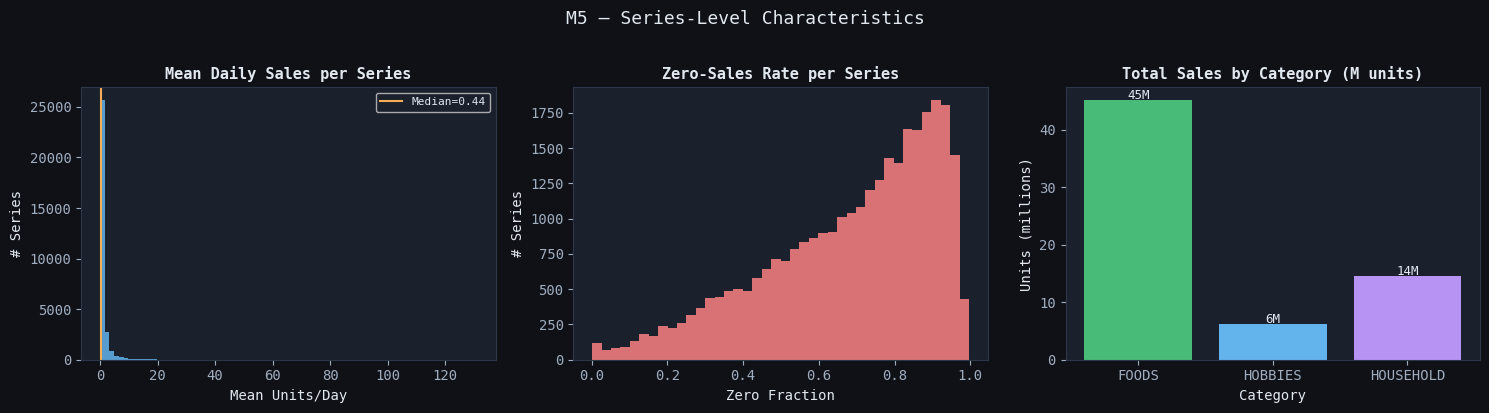

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('M5 — Series-Level Characteristics', fontsize=13, y=1.02)

axes[0].hist(series_mean, bins=80, color=COLORS['blue'], edgecolor='none', alpha=0.85)
axes[0].axvline(np.median(series_mean), color=COLORS['orange'], lw=1.5,
                label=f'Median={np.median(series_mean):.2f}')
axes[0].set_title('Mean Daily Sales per Series')
axes[0].set_xlabel('Mean Units/Day'); axes[0].set_ylabel('# Series')
axes[0].legend(fontsize=8)

zero_days = (sales_vals == 0).mean(axis=1)
axes[1].hist(zero_days, bins=40, color=COLORS['red'], edgecolor='none', alpha=0.85)
axes[1].set_title('Zero-Sales Rate per Series')
axes[1].set_xlabel('Zero Fraction'); axes[1].set_ylabel('# Series')

cat_totals = sales.groupby('cat_id')[day_cols].sum().sum(axis=1)
bars = axes[2].bar(cat_totals.index, cat_totals.values / 1e6,
                   color=[COLORS['green'], COLORS['blue'], COLORS['purple']])
for bar in bars:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.0f}M', ha='center', fontsize=9)
axes[2].set_title('Total Sales by Category (M units)')
axes[2].set_xlabel('Category'); axes[2].set_ylabel('Units (millions)')

plt.tight_layout(); plt.show()


## 3. Temporal Patterns

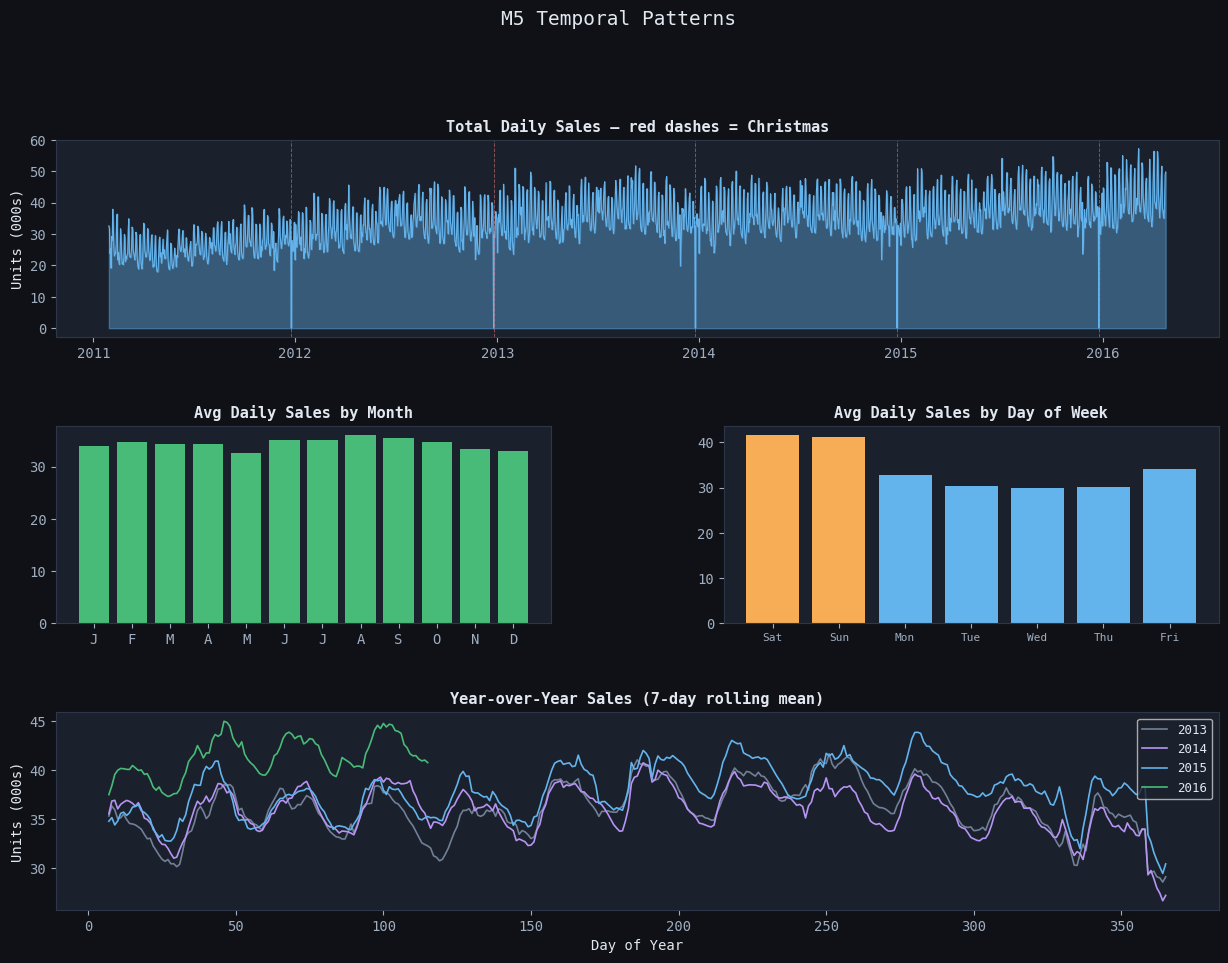

In [7]:
calendar['date'] = pd.to_datetime(calendar['date'])
cal_slim = calendar[['d','date','month','year','weekday','wday',
                      'event_name_1','snap_CA','snap_TX','snap_WI']].copy()

daily_total = pd.DataFrame({
    'd'    : day_cols,
    'sales': sales[day_cols].sum().values,
}).merge(cal_slim, on='d')

fig = plt.figure(figsize=(15, 10))
gs  = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(daily_total['date'], daily_total['sales']/1e3, alpha=0.4, color=COLORS['blue'])
ax1.plot(daily_total['date'], daily_total['sales']/1e3, color=COLORS['blue'], lw=0.8)
xmas = daily_total[(daily_total['date'].dt.month==12) & (daily_total['date'].dt.day==25)]['date']
for d in xmas:
    ax1.axvline(d, color=COLORS['red'], lw=0.7, alpha=0.5, linestyle='--')
ax1.set_title('Total Daily Sales — red dashes = Christmas')
ax1.set_ylabel('Units (000s)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax2 = fig.add_subplot(gs[1, 0])
monthly = daily_total.groupby('month')['sales'].mean()
ax2.bar(monthly.index, monthly.values/1e3, color=COLORS['green'], edgecolor='none')
ax2.set_title('Avg Daily Sales by Month')
ax2.set_xticks(range(1,13))
ax2.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])

ax3 = fig.add_subplot(gs[1, 1])
weekday_order = ['Saturday','Sunday','Monday','Tuesday','Wednesday','Thursday','Friday']
weekly = daily_total.groupby('weekday')['sales'].mean().reindex(weekday_order)
colors_wk = [COLORS['orange'] if d in ['Saturday','Sunday'] else COLORS['blue'] for d in weekday_order]
ax3.bar(range(7), weekly.values/1e3, color=colors_wk, edgecolor='none')
ax3.set_title('Avg Daily Sales by Day of Week')
ax3.set_xticks(range(7))
ax3.set_xticklabels(['Sat','Sun','Mon','Tue','Wed','Thu','Fri'], fontsize=8)

ax4 = fig.add_subplot(gs[2, :])
for yr, col in zip([2013,2014,2015,2016],
                   [COLORS['gray'],COLORS['purple'],COLORS['blue'],COLORS['green']]):
    yd = daily_total[daily_total['year']==yr].copy().sort_values('date')
    yd['doy'] = yd['date'].dt.dayofyear
    ax4.plot(yd['doy'], yd['sales'].rolling(7).mean()/1e3, color=col, lw=1.2, label=str(yr))
ax4.set_title('Year-over-Year Sales (7-day rolling mean)')
ax4.set_xlabel('Day of Year'); ax4.set_ylabel('Units (000s)')
ax4.legend(fontsize=9)

fig.suptitle('M5 Temporal Patterns', fontsize=14, y=1.01)
plt.show()


## 4. SNAP Promotions & Event Effects

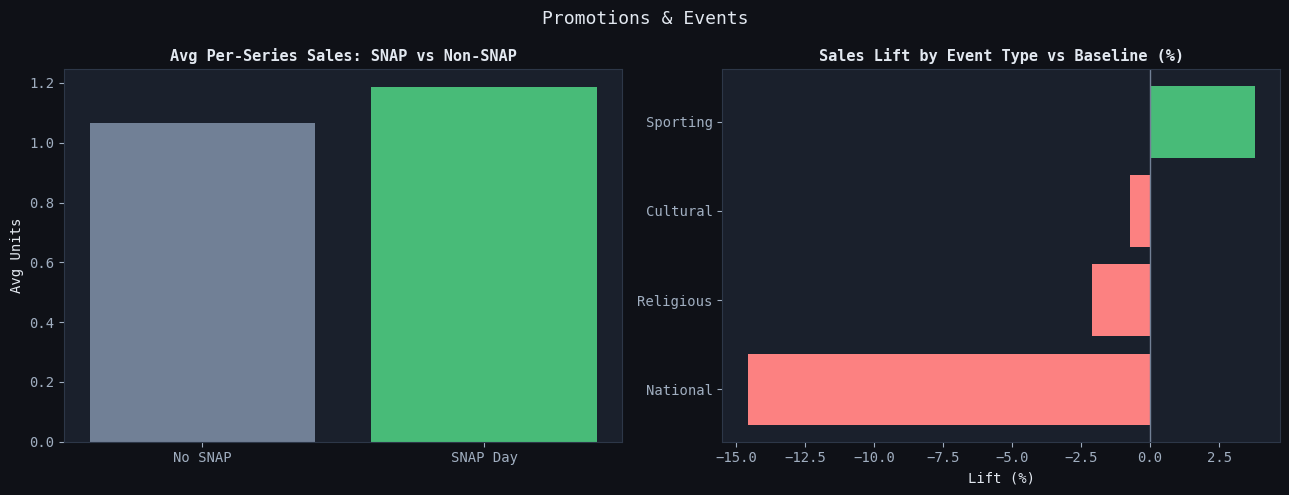

SNAP lift: +11.1%


In [8]:
snap_days    = calendar[calendar[['snap_CA','snap_TX','snap_WI']].any(axis=1)]['d'].tolist()
no_snap_days = calendar[~calendar['d'].isin(snap_days)]['d'].tolist()

snap_sales   = sales[[c for c in snap_days   if c in sales.columns]].mean().mean()
nosnap_sales = sales[[c for c in no_snap_days if c in sales.columns]].mean().mean()
lift = (snap_sales / nosnap_sales - 1) * 100

event_days = calendar[calendar['event_name_1'].notna()].copy()
no_event   = calendar[calendar['event_name_1'].isna()]['d'].tolist()
base_sales = sales[[c for c in no_event if c in sales.columns]].mean().mean()

event_lifts = {}
for etype in event_days['event_type_1'].dropna().unique():
    edays = event_days[event_days['event_type_1']==etype]['d'].tolist()
    valid = [c for c in edays if c in sales.columns]
    if valid:
        event_lifts[etype] = (sales[valid].mean().mean() / base_sales - 1) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Promotions & Events', fontsize=13)

axes[0].bar(['No SNAP','SNAP Day'], [nosnap_sales, snap_sales],
            color=[COLORS['gray'], COLORS['green']], edgecolor='none')
axes[0].set_title('Avg Per-Series Sales: SNAP vs Non-SNAP')
axes[0].set_ylabel('Avg Units')
axes[0].text(1, snap_sales*0.95, f'+{lift:.1f}%', ha='center',
             color=COLORS['green'], fontsize=13, fontweight='bold')

lifts_df = pd.Series(event_lifts).sort_values()
colors_e = [COLORS['green'] if v > 0 else COLORS['red'] for v in lifts_df.values]
axes[1].barh(lifts_df.index, lifts_df.values, color=colors_e, edgecolor='none')
axes[1].axvline(0, color=COLORS['gray'], lw=1)
axes[1].set_title('Sales Lift by Event Type vs Baseline (%)')
axes[1].set_xlabel('Lift (%)')

plt.tight_layout(); plt.show()
print(f'SNAP lift: +{lift:.1f}%')


## 5. Autocorrelation — Justifying Lag Feature Choices

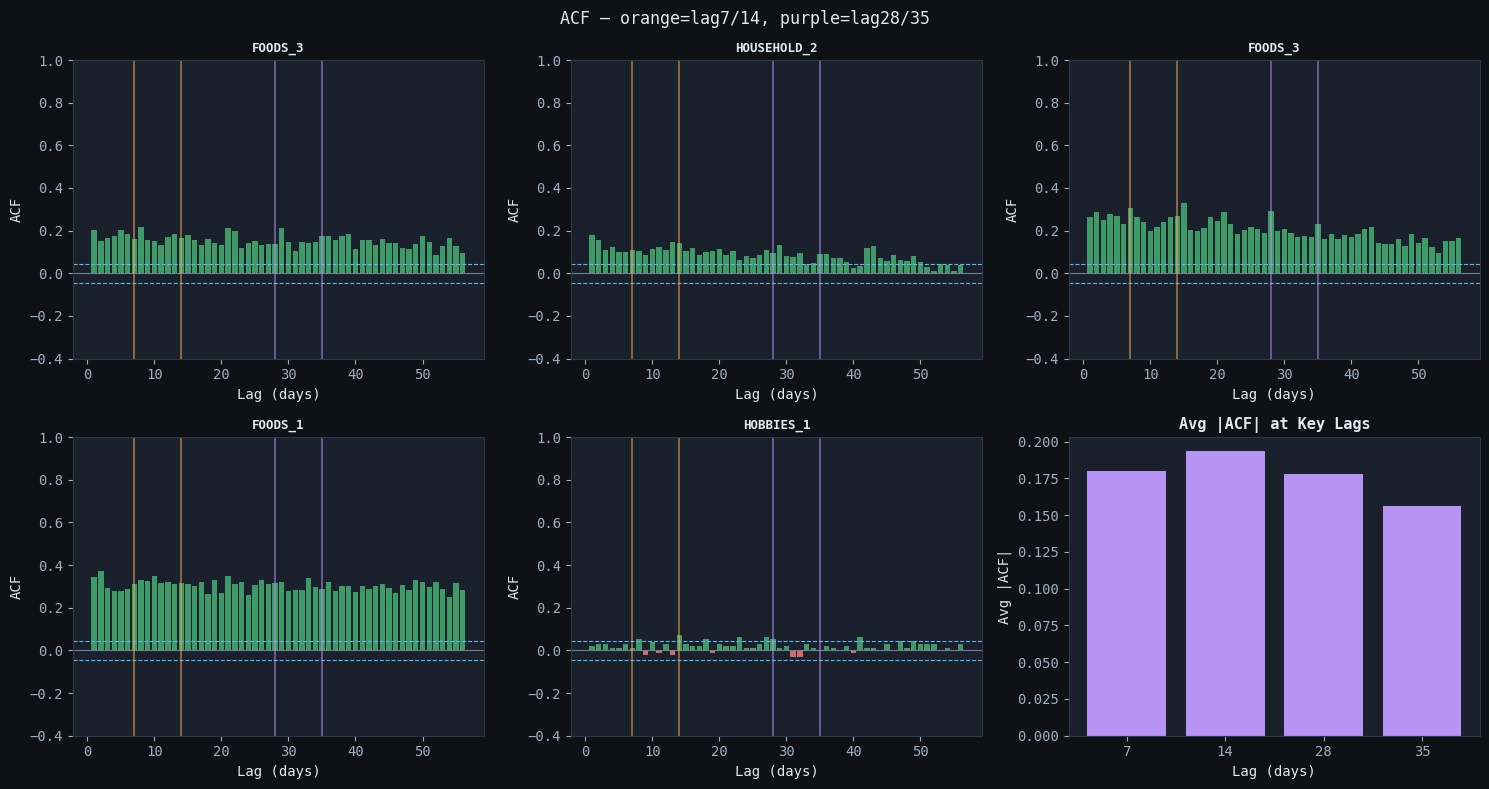

Lag- 7 avg |ACF| = 0.180
Lag-14 avg |ACF| = 0.193
Lag-28 avg |ACF| = 0.178
Lag-35 avg |ACF| = 0.156


In [9]:
sample_ids = sales.sample(5, random_state=42)['id'].values
fig, axes  = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('ACF — orange=lag7/14, purple=lag28/35', fontsize=12)

avg_acf_by_lag = {lag: [] for lag in [7, 14, 28, 35]}

for idx, (sid, ax) in enumerate(zip(sample_ids, axes.flatten())):
    series = sales[sales['id']==sid][day_cols].values.flatten().astype(float)
    series_dm = series - series.mean()
    var = np.var(series_dm) + 1e-8
    lags = range(1, 57)
    acf_vals = [np.mean(series_dm[l:] * series_dm[:-l]) / var for l in lags]
    colors_acf = [COLORS['green'] if v > 0 else COLORS['red'] for v in acf_vals]
    ax.bar(lags, acf_vals, color=colors_acf, edgecolor='none', alpha=0.8)
    ax.axhline(0, color=COLORS['gray'], lw=0.8)
    ci = 1.96 / np.sqrt(len(series))
    ax.axhline(ci,  color=COLORS['blue'], lw=0.8, linestyle='--')
    ax.axhline(-ci, color=COLORS['blue'], lw=0.8, linestyle='--')
    for kl, kc in [(7,COLORS['orange']),(14,COLORS['orange']),
                   (28,COLORS['purple']),(35,COLORS['purple'])]:
        ax.axvline(kl, color=kc, lw=1.2, alpha=0.6)
        avg_acf_by_lag[kl].append(abs(acf_vals[kl-1]))
    ax.set_title(sales[sales['id']==sid]['dept_id'].values[0], fontsize=9)
    ax.set_xlabel('Lag (days)'); ax.set_ylabel('ACF'); ax.set_ylim(-0.4, 1.0)

ax = axes.flatten()[-1]
ax.bar(['7','14','28','35'], [np.mean(avg_acf_by_lag[l]) for l in [7,14,28,35]],
       color=COLORS['purple'], edgecolor='none')
ax.set_title('Avg |ACF| at Key Lags'); ax.set_xlabel('Lag (days)'); ax.set_ylabel('Avg |ACF|')

plt.tight_layout(); plt.show()
for lag in [7,14,28,35]:
    print(f'Lag-{lag:2d} avg |ACF| = {np.mean(avg_acf_by_lag[lag]):.3f}')


## 6. Store × Category Heatmap

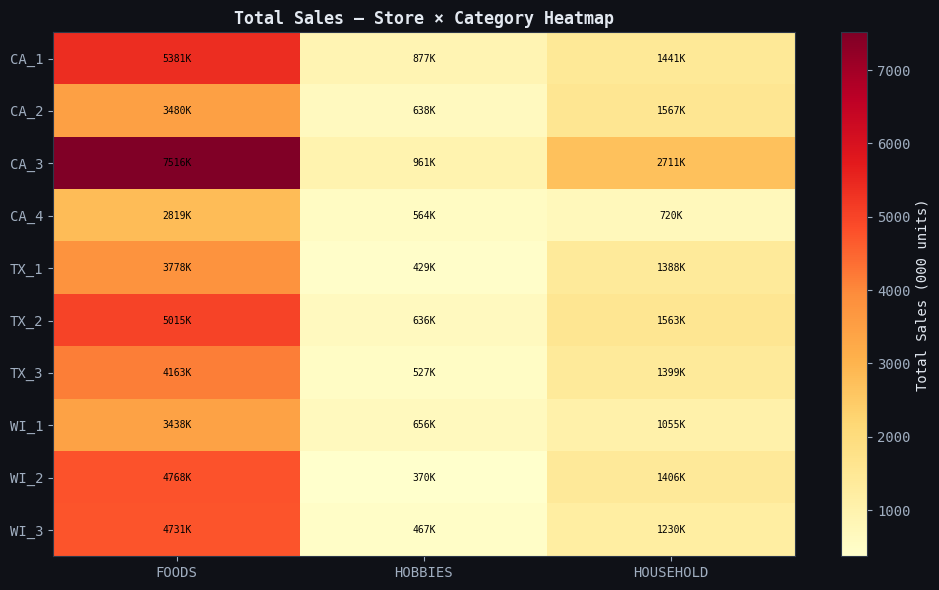

In [10]:
store_cat = (sales.groupby(['store_id','cat_id'])[day_cols]
             .sum().sum(axis=1).unstack('cat_id'))

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(store_cat.values/1e3, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(store_cat.columns))); ax.set_xticklabels(store_cat.columns)
ax.set_yticks(range(len(store_cat.index)));   ax.set_yticklabels(store_cat.index)
plt.colorbar(im, ax=ax, label='Total Sales (000 units)')
for i in range(len(store_cat.index)):
    for j in range(len(store_cat.columns)):
        ax.text(j, i, f'{store_cat.values[i,j]/1e3:.0f}K',
                ha='center', va='center', fontsize=7, color='black')
ax.set_title('Total Sales — Store × Category Heatmap', fontsize=12)
plt.tight_layout(); plt.show()


In [11]:
# EDA Summary
print('Key Findings:')
print(f'  Zero-sales rate : {zero_rate:.1%} -> use quantile loss')
print(f'  SNAP lift       : +{lift:.1f}%   -> include per-state SNAP flag')
print(f'  Strongest lags  : 7, 14, 28, 35 -> confirmed feature choices')
print(f'  FOODS share     : {cat_totals["FOODS"]/cat_totals.sum():.0%} of total volume')
print()
print('Next -> 02_feature_engineering.ipynb')


Key Findings:
  Zero-sales rate : 68.2% -> use quantile loss
  SNAP lift       : +11.1%   -> include per-state SNAP flag
  Strongest lags  : 7, 14, 28, 35 -> confirmed feature choices
  FOODS share     : 69% of total volume

Next -> 02_feature_engineering.ipynb
